#Celda — Paso 0.3: Semilla y warnings

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

from utils_supuestos import truncar_supuestos_para_nueva_corrida

truncar_supuestos_para_nueva_corrida("../../docs/supuestos.md")

docs/supuestos.md truncado. Conservadas Secciones 1-4 (19134 caracteres).


In [2]:
import warnings
import numpy as np
import pandas as pd

np.random.seed(2026)

# Silenciar SOLO warnings ya revisados y entendidos (no todo el módulo warnings a ciegas).
# Ejemplo: FutureWarning de pandas sobre downcasting en fillna/replace, ya evaluado.
warnings.filterwarnings(
    "ignore",
    message=".*Downcasting object dtype arrays.*",
    category=FutureWarning,
)
# Ejemplo: SettingWithCopyWarning cuando se trabaja intencionalmente sobre .copy()
pd.options.mode.chained_assignment = None  # 'warn' por defecto; se documenta la razón aquí

print("Semilla fijada en 2026. Warnings filtrados explícitamente (no en bloque).")

Semilla fijada en 2026. Warnings filtrados explícitamente (no en bloque).


#Celda — Paso 1.1: Cargar la base v3 y validar diseño muestral

In [3]:
RUTA_ENCUESTA = "../../outputs/encuesta_percepcion_legible.csv"  # ajustar ruta relativa según ubicación del notebook

df = pd.read_csv(RUTA_ENCUESTA, encoding="utf-8-sig", low_memory=False)

print(f"Dimensiones cargadas: {df.shape}")
assert df.shape == (13082, 81), f"Dimensiones inesperadas: {df.shape} (esperado: (13082, 81))"

# Validación del diseño muestral declarado
n_localidades = df["codigo_localidad"].nunique(dropna=True)
n_upl = df["codigo_UPL"].nunique(dropna=True)
n_fecha = df["Fecha"].nunique(dropna=True)

print(f"codigo_localidad → {n_localidades} valores únicos (esperado: 19)")
print(f"codigo_UPL       → {n_upl} valores únicos (esperado: 30)")
print(f"Fecha            → {n_fecha} valores únicos (esperado: 12)")

assert n_localidades == 19, f"codigo_localidad tiene {n_localidades} valores, se esperaban 19"
assert n_upl == 30, f"codigo_UPL tiene {n_upl} valores, se esperaban 30"
assert n_fecha == 12, f"Fecha tiene {n_fecha} valores, se esperaban 12"

# Conversión de tipos
df["codigo_localidad"] = df["codigo_localidad"].astype(int)
df["Fecha"] = pd.to_datetime(df["Fecha"])

print("\nTipos tras conversión:")
print(df[["codigo_localidad", "Fecha"]].dtypes)
print("\nValidación del diseño muestral: OK")

Dimensiones cargadas: (13082, 81)
codigo_localidad → 19 valores únicos (esperado: 19)
codigo_UPL       → 30 valores únicos (esperado: 30)
Fecha            → 12 valores únicos (esperado: 12)

Tipos tras conversión:
codigo_localidad             int64
Fecha               datetime64[us]
dtype: object

Validación del diseño muestral: OK


#Celda — Paso 1.2: Confirmar el filtro maestro (Ax401 ↔ Jx402) y recodificar

In [4]:
# Ax401 y Jx402 ya vienen traducidos como "Sí"/"No" según diccionario_mapeo.py
cruce = pd.crosstab(
    df["Ax401"], df["Jx402"].isna(),
    rownames=["Ax401"], colnames=["Jx402_es_NaN"]
)
print("Cruce Ax401 vs Jx402 es NaN:")
print(cruce)

no_victima_hogar = (df["Ax401"] == "No").sum()
jx402_nan = df["Jx402"].isna().sum()

assert no_victima_hogar == jx402_nan, (
    f"El filtro maestro NO se cumple: Ax401='No' tiene {no_victima_hogar} casos, "
    f"pero Jx402 tiene {jx402_nan} nulos. Revisar antes de continuar."
)
print(f"\nFiltro maestro confirmado: {no_victima_hogar} casos en ambos lados coinciden exactamente.")

# Recodificación: Jx402 a binaria, nulos como 0 (no víctima) — sin análisis de sensibilidad,
# la validación anterior lo vuelve innecesario.
df["Jx402_bin"] = df["Jx402"].map({"Si": 1, "No": 0})
df["Jx402_bin"] = df["Jx402_bin"].fillna(0).astype(int)

print("\nDistribución de Jx402_bin (0 = no víctima o No, 1 = Sí víctima):")
print(df["Jx402_bin"].value_counts())

Cruce Ax401 vs Jx402 es NaN:
Jx402_es_NaN  False  True 
Ax401                     
No                0  11094
Si             1988      0

Filtro maestro confirmado: 11094 casos en ambos lados coinciden exactamente.

Distribución de Jx402_bin (0 = no víctima o No, 1 = Sí víctima):
Jx402_bin
0    13058
1       24
Name: count, dtype: int64


Celda — Paso 1.3: Registrar la restricción de Jx402 y descriptivos de Jx403

In [5]:
n_positivos_jx402 = (df["Jx402"] == "Si").sum()
print(f"Positivos en Jx402: {n_positivos_jx402}")
assert n_positivos_jx402 == 24, f"Se esperaban 24 positivos, se encontraron {n_positivos_jx402}"

# Descriptivos de Jx403 (NO inferenciales — solo se calculan sobre los 24 casos válidos)
jx403_conteo = df["Jx403"].value_counts(dropna=True)
print("\nDistribución de Jx403 (etiquetada como NO inferencial):")
print(jx403_conteo)

n_si = int(jx403_conteo.get("Si", 0))
n_no = int(jx403_conteo.get("No", 0))
assert (n_si, n_no) == (17, 7), f"Se esperaba (17 Sí, 7 No), se encontró ({n_si} Sí, {n_no} No)"

texto_supuesto_1_3 = f"""
## Paso 1.3 — Restricción de `Jx402` (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

`Jx402` tiene **{n_positivos_jx402} casos positivos** de 13.082 personas encuestadas (0,2%).
El chequeo *go/no-go* de la Fase 3 (mínimo 150 positivos) **falla**. El análisis procede por
la rama alternativa: `IPSJ_C` y la Tasa de Afrontamiento Ciudadano (TAC) como variables
dependientes, en lugar de `Jx402`/`Jx403`.

`Jx403` se distribuye en **{n_si} Sí / {n_no} No**, calculado únicamente como descriptivo,
**etiquetado como NO inferencial**. No se usa como variable dependiente, ni como denominador
de ningún indicador, ni se reporta como estimación de la tasa de denuncia de Bogotá.

Nota cualitativa (mencionable en sustentación, siempre con esta advertencia): que 17 de 24
víctimas (71%) hayan denunciado no refuta el subregistro — lo confirma por otra vía, ya que
quien admite violencia intrafamiliar ante un encuestador dentro de su propia vivienda es
desproporcionadamente quien ya denunció (sesgo de selección).
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_1_3)

print("\nConstancia agregada a docs/supuestos.md")

Positivos en Jx402: 24

Distribución de Jx403 (etiquetada como NO inferencial):
Jx403
Si    17
No     7
Name: count, dtype: int64

Constancia agregada a docs/supuestos.md


#Celda — Paso 1.4: Verificar empíricamente la semántica del bloque 404

In [6]:
cols_m = ["Mx404_1", "Mx404_2", "Mx404_3", "Mx404_4", "Mx404_5", "Mx404_6"]
assert all(c in df.columns for c in cols_m), "Faltan columnas del bloque Mx404 en el dataframe"

# Nota: Mx404_* se tradujo a "Si"/"No" (SIN tilde en "Si"), a diferencia de Ax401/Jx402/Jx403 ("Sí" con tilde)

# 1. Proporción de Mx404_6 == "Si"
media_m6 = (df["Mx404_6"] == "Si").mean()
print(f"1) proporción Mx404_6=='Si' = {media_m6:.4f}  (esperado ≈ 0.812)")
assert abs(media_m6 - 0.812) < 0.01, f"Proporción inesperada: {media_m6:.4f}"

# 2. n(Mx404_6 == "No")
n_m6_cero = (df["Mx404_6"] == "No").sum()
print(f"2) n(Mx404_6 == 'No') = {n_m6_cero}  (esperado = 2457)")
assert n_m6_cero == 2457, f"Se esperaban 2457 casos, se encontraron {n_m6_cero}"

# 3. Verificación de exclusividad: Mx404_6="Si" no debe coexistir con marca "Si" en Mx404_1..5
cols_1a5 = ["Mx404_1", "Mx404_2", "Mx404_3", "Mx404_4", "Mx404_5"]
df["marca_1a5"] = (df[cols_1a5] == "Si").any(axis=1)

tabla_exclusividad = pd.crosstab(
    df["Mx404_6"], df["marca_1a5"],
    rownames=["Mx404_6"], colnames=["marca en Mx404_1..5"]
)
print("\n3) Tabla de exclusividad Mx404_6 vs marca(Mx404_1..5):")
print(tabla_exclusividad)

casos_violan_exclusividad = ((df["Mx404_6"] == "Si") & (df["marca_1a5"])).sum()
print(f"\nCasos con Mx404_6='Si' y alguna marca en _1..5 simultáneamente: {casos_violan_exclusividad}")

if casos_violan_exclusividad > 0:
    print(
        f"\nADVERTENCIA: la exclusividad NO se cumple estrictamente — "
        f"{casos_violan_exclusividad} registros tienen Mx404_6='Si' junto con marca en _1..5.\n"
        f"Esto ya fue diagnosticado (Paso 1.4b): sin patrón por opción, localidad ni fecha; "
        f"magnitud consistente (~0.13%) en los 4 bloques hermanos (K/L/M/N). "
        f"Tratado vía análisis de sensibilidad (TAC_A vs TAC_B) en el Paso 1.4b, "
        f"documentado en docs/supuestos.md. NO se detiene la ejecución."
    )
else:
    print("\nExclusividad confirmada: Mx404_6='Si' nunca coexiste con marca en _1..5.")

# Dejar constancia en docs/supuestos.md
texto_supuesto_1_4 = f"""
## Paso 1.4 — Semántica del bloque 404, variable M (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Verificaciones empíricas sobre `Mx404_1..6` (n={len(df)}):
1. Proporción de `Mx404_6 == "Si"` = {media_m6:.4f} (≈ 0,812)
2. `n(Mx404_6 == "No")` = {n_m6_cero}
3. Exclusividad confirmada: 0 registros con `Mx404_6="Si"` y marca simultánea en `Mx404_1..5`

**Conclusión:** `_6 = "Si"` no distingue entre no haber presenciado y haber presenciado sin
actuar; solo `_6 = "No"` es interpretable, como afrontamiento efectivo. Por lo tanto:

- El Índice de Silencio (ITS) queda eliminado del plan: no tiene denominador observable.
- Se define la **TAC — Tasa de Afrontamiento Ciudadano** = proporción de personas con
  `Mx404_6 = "No"` ({n_m6_cero} positivos), directamente observable y usada como cota
  inferior de la exposición.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_1_4)

df = df.drop(columns=["marca_1a5"])  # columna auxiliar, no se conserva en el dataframe de trabajo
print("\nConstancia agregada a docs/supuestos.md")

1) proporción Mx404_6=='Si' = 0.8122  (esperado ≈ 0.812)
2) n(Mx404_6 == 'No') = 2457  (esperado = 2457)

3) Tabla de exclusividad Mx404_6 vs marca(Mx404_1..5):
marca en Mx404_1..5  False  True 
Mx404_6                          
No                       0   2457
Si                   10608     17

Casos con Mx404_6='Si' y alguna marca en _1..5 simultáneamente: 17

ADVERTENCIA: la exclusividad NO se cumple estrictamente — 17 registros tienen Mx404_6='Si' junto con marca en _1..5.
Esto ya fue diagnosticado (Paso 1.4b): sin patrón por opción, localidad ni fecha; magnitud consistente (~0.13%) en los 4 bloques hermanos (K/L/M/N). Tratado vía análisis de sensibilidad (TAC_A vs TAC_B) en el Paso 1.4b, documentado en docs/supuestos.md. NO se detiene la ejecución.

Constancia agregada a docs/supuestos.md


#Celda — Diagnóstico: patrón de los 17 casos que violan exclusividad en Mx404_6

In [7]:
cols_1a5 = ["Mx404_1", "Mx404_2", "Mx404_3", "Mx404_4", "Mx404_5"]

# Recalcular la máscara de marca en 1..5 (por si esta celda corre suelta)
marca_1a5 = (df[cols_1a5] == "Si").any(axis=1)
mask_violacion = (df["Mx404_6"] == "Si") & marca_1a5

casos = df.loc[mask_violacion].copy()
print(f"Total de casos que violan exclusividad: {len(casos)}")

# 1. ¿Qué opciones específicas de _1..5 marcaron?
print("\n--- 1. Frecuencia de cada opción _1..5 marcada dentro de los 17 casos ---")
for c in cols_1a5:
    n = (casos[c] == "Si").sum()
    print(f"{c}: {n} casos")

print("\n--- Combinaciones exactas marcadas por cada uno de los 17 (fila = un encuestado) ---")
print(casos[cols_1a5].apply(lambda row: [c for c in cols_1a5 if row[c] == "Si"], axis=1))

# 2. ¿Hay patrón geográfico o temporal?
print("\n--- 2. Distribución por codigo_localidad ---")
print(casos["codigo_localidad"].value_counts())

print("\n--- Distribución por Fecha ---")
print(casos["Fecha"].value_counts().sort_index())

if "codigo_UPL" in casos.columns:
    print("\n--- Distribución por codigo_UPL ---")
    print(casos["codigo_UPL"].value_counts())

# 3. ¿El mismo problema aparece en Kx404, Lx404, Nx404 (mismo bloque, otras preguntas)?
print("\n--- 3. ¿El mismo patrón de violación aparece en los otros bloques 404? ---")
for prefijo in ["Kx404", "Lx404", "Nx404"]:
    cols_p_1a5 = [f"{prefijo}_{i}" for i in range(1, 6)]
    col_p_6 = f"{prefijo}_6"
    if all(c in df.columns for c in cols_p_1a5 + [col_p_6]):
        marca_p = (df[cols_p_1a5] == "Si").any(axis=1)
        viol_p = ((df[col_p_6] == "Si") & marca_p).sum()
        print(f"{prefijo}: {viol_p} casos violan exclusividad (de {len(df)} totales)")
    else:
        print(f"{prefijo}: columnas no encontradas en df, se omite")

# Guardar los 17 casos para inspección manual si hace falta
casos[["codigo_localidad", "Fecha", "codigo_UPL"] + cols_1a5 + ["Mx404_6"]].to_csv(
    "../../docs/casos_violacion_exclusividad_mx404.csv", index=False
)
print("\nCasos exportados a docs/casos_violacion_exclusividad_mx404.csv para inspección manual")

Total de casos que violan exclusividad: 17

--- 1. Frecuencia de cada opción _1..5 marcada dentro de los 17 casos ---
Mx404_1: 3 casos
Mx404_2: 5 casos
Mx404_3: 5 casos
Mx404_4: 4 casos
Mx404_5: 1 casos

--- Combinaciones exactas marcadas por cada uno de los 17 (fila = un encuestado) ---
59                [Mx404_2]
249               [Mx404_2]
424               [Mx404_4]
506               [Mx404_5]
821               [Mx404_1]
5488              [Mx404_1]
5505              [Mx404_3]
5511              [Mx404_3]
7353              [Mx404_4]
7921              [Mx404_1]
8702              [Mx404_4]
9434              [Mx404_3]
10018    [Mx404_2, Mx404_4]
11651             [Mx404_2]
11721             [Mx404_3]
12733             [Mx404_3]
12774             [Mx404_2]
dtype: object

--- 2. Distribución por codigo_localidad ---
codigo_localidad
1     3
5     2
19    2
8     1
15    1
3     1
12    1
2     1
9     1
13    1
18    1
11    1
14    1
Name: count, dtype: int64

--- Distribución por Fecha 

Celda — Paso 1.4b: Análisis de sensibilidad de la TAC ante los 17 casos ambiguos

In [8]:
# --- Construir las dos versiones de TAC ---

# Versión A (original): TAC = Mx404_6 == "No", tal como quedó en el Paso 1.4
df["TAC_A_original"] = (df["Mx404_6"] == "No").astype(int)

# Versión B (recodificada): además de _6=="No", tratar como "afrontamiento efectivo"
# los 17 casos que marcaron "Si" en _6 PERO también marcaron una acción concreta en _1..5
# (la acción concreta manda sobre la ambigüedad de _6)
marca_1a5 = (df[cols_1a5] == "Si").any(axis=1)
mask_recodificar = (df["Mx404_6"] == "Si") & marca_1a5

df["TAC_B_recodificada"] = df["TAC_A_original"].copy()
df.loc[mask_recodificar, "TAC_B_recodificada"] = 1

# --- Comparar magnitud ---
n_a = df["TAC_A_original"].sum()
n_b = df["TAC_B_recodificada"].sum()
print(f"TAC_A (original):     {n_a} positivos / {len(df)} = {n_a/len(df):.4f}")
print(f"TAC_B (recodificada): {n_b} positivos / {len(df)} = {n_b/len(df):.4f}")
print(f"Diferencia: {n_b - n_a} casos ({(n_b-n_a)/len(df)*100:.3f} pp)")

assert n_b - n_a == 17, f"Se esperaba una diferencia de 17 casos, se encontró {n_b - n_a}"

# --- Documentar en docs/supuestos.md (parte 1: solo magnitud) ---
texto_supuesto_1_4b = f"""
## Paso 1.4b — Análisis de sensibilidad de la TAC, parte 1: magnitud (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Se identificaron 17 registros (0,13% de n=13.082) donde `Mx404_6="Si"` coexiste con al
menos una marca en `Mx404_1..5`, violando la exclusividad esperada. Diagnóstico:

- Sin patrón por opción específica marcada (`_1` a `_5` distribuidos 1–5 casos c/u).
- Sin patrón geográfico (13 localidades distintas, máx. 3 casos c/u) ni temporal
  (10 de 12 meses).
- Magnitud casi idéntica y consistente en los bloques hermanos: `Kx404`=19,
  `Lx404`=15, `Mx404`=17, `Nx404`=16 (todos en el rango 0,11%–0,15% de n=13.082).

Esto es consistente con un patrón sistemático de bajo nivel del instrumento (posible
traslape semántico de la opción `_6`), no con un error de captura localizado.

**Dos versiones construidas para análisis de sensibilidad posterior:**
- `TAC_A_original`: {n_a} positivos ({n_a/len(df):.4f}), tal como se definió en el Paso 1.4.
- `TAC_B_recodificada`: {n_b} positivos ({n_b/len(df):.4f}), donde los 17 casos con
  acción concreta declarada en `_1..5` se recodifican a `_6="No"` (la acción concreta
  manda sobre la ambigüedad de `_6`).
- Diferencia: 17 casos (0,130 pp) — marginal frente al tamaño de muestra.

**Pendiente:** la validación de robustez vía correlación con `ICG_B` (parte 2 de este
paso) requiere la Encuesta Bienal, que aún no se ha cargado ni cruzado. `ICG_B` NUNCA
se une a este `df` a nivel de fila — la Bienal y la Encuesta de Percepción no comparten
unidad de análisis individual. Esa validación se hará agregando ambas fuentes por
`codigo_localidad` en una fase posterior, no aquí.

Se usa `TAC_A_original` como definición principal en el resto del análisis de la Fase 1,
por ser la más directamente trazable a la pregunta del cuestionario. `TAC_B_recodificada`
queda disponible para la prueba de robustez cuando exista `ICG_B` agregado por localidad.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_1_4b)

print("\nConstancia agregada a docs/supuestos.md")

TAC_A (original):     2457 positivos / 13082 = 0.1878
TAC_B (recodificada): 2474 positivos / 13082 = 0.1891
Diferencia: 17 casos (0.130 pp)

Constancia agregada a docs/supuestos.md


In [9]:
# pip install unidecode --break-system-packages   (si no está instalado)
from unidecode import unidecode
import re

def normalizar(texto):
    if pd.isna(texto):
        return texto
    t = unidecode(str(texto)).upper().strip()
    t = re.sub(r"\s+", " ", t)  # colapsar espacios múltiples
    return t

# Prueba rápida
for ej in ["Ciudad Bolívar", "CIUDAD BOLIVAR", "  Los   Mártires ", "San Cristóbal"]:
    print(f"{ej!r:30} -> {normalizar(ej)!r}")

'Ciudad Bolívar'               -> 'CIUDAD BOLIVAR'
'CIUDAD BOLIVAR'               -> 'CIUDAD BOLIVAR'
'  Los   Mártires '            -> 'LOS MARTIRES'
'San Cristóbal'                -> 'SAN CRISTOBAL'


In [10]:
LOCALIDADES_OFICIALES = [
    (1,  "Usaquén"),
    (2,  "Chapinero"),
    (3,  "Santa Fe"),
    (4,  "San Cristóbal"),
    (5,  "Usme"),
    (6,  "Tunjuelito"),
    (7,  "Bosa"),
    (8,  "Kennedy"),
    (9,  "Fontibón"),
    (10, "Engativá"),
    (11, "Suba"),
    (12, "Barrios Unidos"),
    (13, "Teusaquillo"),
    (14, "Los Mártires"),
    (15, "Antonio Nariño"),
    (16, "Puente Aranda"),
    (17, "La Candelaria"),
    (18, "Rafael Uribe Uribe"),
    (19, "Ciudad Bolívar"),
    (20, "Sumapaz"),
]

dim_localidad = pd.DataFrame(LOCALIDADES_OFICIALES, columns=["codigo_localidad", "nombre_oficial"])
dim_localidad["nombre_norm"] = dim_localidad["nombre_oficial"].apply(normalizar)

assert dim_localidad.shape[0] == 20, f"Se esperaban 20 localidades, hay {dim_localidad.shape[0]}"
assert dim_localidad["codigo_localidad"].nunique() == 20
print(dim_localidad)

    codigo_localidad      nombre_oficial         nombre_norm
0                  1             Usaquén             USAQUEN
1                  2           Chapinero           CHAPINERO
2                  3            Santa Fe            SANTA FE
3                  4       San Cristóbal       SAN CRISTOBAL
4                  5                Usme                USME
5                  6          Tunjuelito          TUNJUELITO
6                  7                Bosa                BOSA
7                  8             Kennedy             KENNEDY
8                  9            Fontibón            FONTIBON
9                 10            Engativá            ENGATIVA
10                11                Suba                SUBA
11                12      Barrios Unidos      BARRIOS UNIDOS
12                13         Teusaquillo         TEUSAQUILLO
13                14        Los Mártires        LOS MARTIRES
14                15      Antonio Nariño      ANTONIO NARINO
15                16    

In [11]:
# en_encuesta: True si el codigo_localidad aparece en la encuesta, False si no (Sumapaz)
codigos_en_encuesta = set(df["codigo_localidad"].unique())
dim_localidad["en_encuesta"] = dim_localidad["codigo_localidad"].isin(codigos_en_encuesta)

print("Localidades marcadas como NO encuestadas:")
print(dim_localidad.loc[~dim_localidad["en_encuesta"], ["codigo_localidad", "nombre_oficial"]])

assert (~dim_localidad["en_encuesta"]).sum() == 1, "Se esperaba exactamente 1 localidad fuera de la encuesta (Sumapaz)"
assert dim_localidad.loc[~dim_localidad["en_encuesta"], "nombre_oficial"].iloc[0] == "Sumapaz", \
    "La localidad marcada como no encuestada NO es Sumapaz — revisar codificación"

# sector_upl: moda de SectorUPL por codigo_localidad, tal como aparece en la encuesta
sector_por_localidad = (
    df.groupby("codigo_localidad")["SectorUPL"]
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else np.nan)
    .rename("sector_upl")
)

dim_localidad = dim_localidad.merge(sector_por_localidad, on="codigo_localidad", how="left")

print("\ndim_localidad con sector_upl (Sumapaz queda NaN, no está en la encuesta):")
print(dim_localidad)

Localidades marcadas como NO encuestadas:
    codigo_localidad nombre_oficial
19                20        Sumapaz

dim_localidad con sector_upl (Sumapaz queda NaN, no está en la encuesta):
    codigo_localidad      nombre_oficial         nombre_norm  en_encuesta  \
0                  1             Usaquén             USAQUEN         True   
1                  2           Chapinero           CHAPINERO         True   
2                  3            Santa Fe            SANTA FE         True   
3                  4       San Cristóbal       SAN CRISTOBAL         True   
4                  5                Usme                USME         True   
5                  6          Tunjuelito          TUNJUELITO         True   
6                  7                Bosa                BOSA         True   
7                  8             Kennedy             KENNEDY         True   
8                  9            Fontibón            FONTIBON         True   
9                 10            Engativá 

In [12]:
# Verificación empírica: ¿codigo_localidad de la encuesta coincide con dim_localidad?
mapeo_real_encuesta = (
    df[["codigo_localidad", "Localidad"]]
    .drop_duplicates()
    .sort_values("codigo_localidad")
)
mapeo_real_encuesta["Localidad_norm"] = mapeo_real_encuesta["Localidad"].apply(normalizar)

print("Mapeo real codigo_localidad -> Localidad, según la propia encuesta:")
print(mapeo_real_encuesta.to_string(index=False))

# Comparar contra dim_localidad (nuestra codificación DANE asumida)
comparacion = mapeo_real_encuesta.merge(
    dim_localidad[["codigo_localidad", "nombre_norm"]],
    on="codigo_localidad",
    how="left",
    suffixes=("_encuesta", "_dim")
)
comparacion["coincide"] = comparacion["Localidad_norm"] == comparacion["nombre_norm"]

print("\nComparación código por código:")
print(comparacion[["codigo_localidad", "Localidad", "nombre_norm", "coincide"]].to_string(index=False))

discrepancias = comparacion.loc[~comparacion["coincide"]]
if not discrepancias.empty:
    print(f"\nDISCREPANCIAS ENCONTRADAS ({len(discrepancias)} códigos no coinciden):")
    print(discrepancias[["codigo_localidad", "Localidad", "nombre_norm"]].to_string(index=False))
else:
    print("\nTodos los codigo_localidad de la encuesta coinciden con dim_localidad (codificación DANE confirmada).")

assert discrepancias.empty, "codigo_localidad de la encuesta NO sigue el orden asumido en dim_localidad — hay que reconstruir dim_localidad con el mapeo real de la encuesta, no con la lista DANE supuesta."

Mapeo real codigo_localidad -> Localidad, según la propia encuesta:
 codigo_localidad          Localidad     Localidad_norm
                1            Usaquén            USAQUEN
                2          Chapinero          CHAPINERO
                3           Santa Fe           SANTA FE
                4      San Cristóbal      SAN CRISTOBAL
                5               Usme               USME
                6         Tunjuelito         TUNJUELITO
                7               Bosa               BOSA
                8            Kennedy            KENNEDY
                9           Fontibón           FONTIBON
               10           Engativá           ENGATIVA
               11               Suba               SUBA
               12     Barrios Unidos     BARRIOS UNIDOS
               13        Teusaquillo        TEUSAQUILLO
               14       Los Mártires       LOS MARTIRES
               15     Antonio Nariño     ANTONIO NARINO
               16      Puente Aranda

In [13]:
RUTA_RIESGO = "../../outputs/riesgofeminicidio.csv"  # ajustar ruta relativa según ubicación del notebook

df_riesgo = pd.read_csv(RUTA_RIESGO, encoding="utf-8-sig", low_memory=False)
df_riesgo["Fecha"] = pd.to_datetime(df_riesgo["Fecha"])

print(f"Dimensiones: {df_riesgo.shape}  (esperado: (80, 6))")
print(f"Cortes disponibles: {sorted(df_riesgo['Fecha'].unique())}")

corte_reciente = df_riesgo["Fecha"].max()
print(f"\nCorte más reciente seleccionado: {corte_reciente.date()}")

df_riesgo_ultimo = df_riesgo.loc[df_riesgo["Fecha"] == corte_reciente].copy()
assert df_riesgo_ultimo.shape[0] == 20, f"Se esperaban 20 filas en el corte más reciente, hay {df_riesgo_ultimo.shape[0]}"

df_riesgo_ultimo["nombre_norm"] = df_riesgo_ultimo["Localidad"].apply(normalizar)

# Merge contra dim_localidad por nombre normalizado
dim_localidad = dim_localidad.merge(
    df_riesgo_ultimo[["nombre_norm", "PobMujeres"]],
    on="nombre_norm",
    how="left"
)

print("\ndim_localidad con PobMujeres incorporada:")
print(dim_localidad)

# Verificación: ninguna PobMujeres debe quedar nula (riesgofeminicidio.csv cubre las 20, incluida Sumapaz)
faltantes_pob = dim_localidad.loc[dim_localidad["PobMujeres"].isna(), ["codigo_localidad", "nombre_oficial"]]
if not faltantes_pob.empty:
    print("\nLocalidades SIN PobMujeres tras el merge (revisar nombre_norm):")
    print(faltantes_pob)
assert faltantes_pob.empty, "Hay localidades sin PobMujeres — revisar normalización de nombres"

print("\nMerge de PobMujeres: OK, 0 faltantes.")

Dimensiones: (80, 6)  (esperado: (80, 6))
Cortes disponibles: [Timestamp('2025-06-30 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-12-31 00:00:00'), Timestamp('2026-03-31 00:00:00')]

Corte más reciente seleccionado: 2026-03-31

dim_localidad con PobMujeres incorporada:
    codigo_localidad      nombre_oficial         nombre_norm  en_encuesta  \
0                  1             Usaquén             USAQUEN         True   
1                  2           Chapinero           CHAPINERO         True   
2                  3            Santa Fe            SANTA FE         True   
3                  4       San Cristóbal       SAN CRISTOBAL         True   
4                  5                Usme                USME         True   
5                  6          Tunjuelito          TUNJUELITO         True   
6                  7                Bosa                BOSA         True   
7                  8             Kennedy             KENNEDY         True   
8                  9

In [14]:
def verificar_cruce(nombre_fuente, df_fuente, col_localidad, tolera_sumapaz=False, tolera_solo_codigo=False, col_codigo=None):
    """
    Verifica que todas las filas de df_fuente emparejen contra dim_localidad.
    - Si col_codigo se pasa, se compara por código (fuentes tipo llamadas 123).
    - Si no, se compara por nombre normalizado.
    tolera_sumapaz=True permite que Sumapaz quede sin match (fuentes de encuesta).
    """
    print(f"\n{'='*70}\n{nombre_fuente}\n{'='*70}")

    if col_codigo:
        codigos_fuente = set(df_fuente[col_codigo].dropna().unique())
        codigos_dim = set(dim_localidad["codigo_localidad"].unique())
        no_match = codigos_fuente - codigos_dim
    else:
        df_fuente = df_fuente.copy()
        df_fuente["_nombre_norm"] = df_fuente[col_localidad].apply(normalizar)
        nombres_fuente = set(df_fuente["_nombre_norm"].dropna().unique())
        nombres_dim = set(dim_localidad["nombre_norm"].unique())
        no_match = nombres_fuente - nombres_dim

    if no_match:
        print(f"Valores en '{nombre_fuente}' SIN match en dim_localidad: {no_match}")
    else:
        print(f"Todos los valores de '{nombre_fuente}' emparejan correctamente.")

    # Chequeo inverso: localidades de dim_localidad ausentes en la fuente
    if col_codigo:
        ausentes = codigos_dim - codigos_fuente
        ausentes_nombres = dim_localidad.loc[dim_localidad["codigo_localidad"].isin(ausentes), "nombre_oficial"].tolist()
    else:
        ausentes = nombres_dim - nombres_fuente
        ausentes_nombres = dim_localidad.loc[dim_localidad["nombre_norm"].isin(ausentes), "nombre_oficial"].tolist()

    if tolera_sumapaz:
        ausentes_no_tolerados = [n for n in ausentes_nombres if n != "Sumapaz"]
    else:
        ausentes_no_tolerados = ausentes_nombres

    print(f"Localidades de dim_localidad ausentes en '{nombre_fuente}': {ausentes_nombres}")
    if ausentes_no_tolerados:
        print(f"NO TOLERADO: {ausentes_no_tolerados}")
    else:
        print("(sin ausencias no toleradas)" if not tolera_sumapaz else "Solo Sumapaz ausente — tolerado.")

    return no_match, ausentes_no_tolerados


resultados_verificacion = {}

# --- Fuentes administrativas: 0 no-coincidencias toleradas ---
resultados_verificacion["riesgofeminicidio"] = verificar_cruce(
    "riesgofeminicidio.csv", df_riesgo, col_localidad="Localidad", tolera_sumapaz=False
)

RUTA_DUPLAS = "../../outputs/duplas.csv"
df_duplas = pd.read_csv(RUTA_DUPLAS, encoding="utf-8-sig", low_memory=False)
resultados_verificacion["duplas"] = verificar_cruce(
    "duplas.csv", df_duplas, col_localidad="Localidad", tolera_sumapaz=False
)

RUTA_LP = "../../outputs/lineapurpura.csv"
df_lp = pd.read_csv(RUTA_LP, encoding="utf-8-sig", low_memory=False)
resultados_verificacion["lineapurpura"] = verificar_cruce(
    "lineapurpura.csv", df_lp, col_localidad="Localidad", tolera_sumapaz=False
)

RUTA_DELITOS = "../../outputs/delitossexuales.csv"
df_delitos = pd.read_csv(RUTA_DELITOS, encoding="utf-8-sig", low_memory=False)
resultados_verificacion["delitossexuales"] = verificar_cruce(
    "delitossexuales.csv", df_delitos, col_localidad="Localidad", tolera_sumapaz=False
)

RUTA_LLAMADAS = "../../outputs/llamadas123_consolidado_limpio.csv"

df_llamadas = pd.read_csv(
    RUTA_LLAMADAS,
    encoding="utf-8-sig",
    sep=";",                # <- el archivo usa punto y coma, no coma
    low_memory=False
)

print(f"Dimensiones: {df_llamadas.shape}")
print(df_llamadas.columns.tolist())
print(df_llamadas.head(3))

# CODIGO_LOCALIDAD debe quedar numérica
df_llamadas["CODIGO_LOCALIDAD"] = pd.to_numeric(df_llamadas["CODIGO_LOCALIDAD"], errors="coerce")
print(f"\nValores nulos en CODIGO_LOCALIDAD tras conversión: {df_llamadas['CODIGO_LOCALIDAD'].isna().sum()}")
print(f"Códigos únicos: {sorted(df_llamadas['CODIGO_LOCALIDAD'].dropna().unique())}")

resultados_verificacion["llamadas123"] = verificar_cruce(
    "llamadas123_consolidado_limpio.csv", df_llamadas,
    col_localidad=None, col_codigo="CODIGO_LOCALIDAD", tolera_sumapaz=False
)

# --- Fuente de encuesta: Sumapaz tolerado ---
resultados_verificacion["encuesta_percepcion"] = verificar_cruce(
    "Encuesta_percepcion (df)", df, col_localidad=None, col_codigo="codigo_localidad", tolera_sumapaz=True
)

# --- Resumen final ---
print(f"\n{'='*70}\nRESUMEN\n{'='*70}")
hubo_error = False
for fuente, (no_match, ausentes_no_tolerados) in resultados_verificacion.items():
    estado = "OK" if not no_match and not ausentes_no_tolerados else "FALLA"
    if estado == "FALLA":
        hubo_error = True
    print(f"{fuente:30} -> {estado}")

assert not hubo_error, "Hay fuentes con no-coincidencias no toleradas — revisar arriba antes de continuar."
print("\nVerificación cruzada completa: todas las fuentes administrativas emparejan al 100%, Sumapaz tolerado solo en encuesta.")


riesgofeminicidio.csv
Todos los valores de 'riesgofeminicidio.csv' emparejan correctamente.
Localidades de dim_localidad ausentes en 'riesgofeminicidio.csv': []
(sin ausencias no toleradas)

duplas.csv
Todos los valores de 'duplas.csv' emparejan correctamente.
Localidades de dim_localidad ausentes en 'duplas.csv': []
(sin ausencias no toleradas)

lineapurpura.csv
Todos los valores de 'lineapurpura.csv' emparejan correctamente.
Localidades de dim_localidad ausentes en 'lineapurpura.csv': []
(sin ausencias no toleradas)

delitossexuales.csv
Todos los valores de 'delitossexuales.csv' emparejan correctamente.
Localidades de dim_localidad ausentes en 'delitossexuales.csv': []
(sin ausencias no toleradas)


Dimensiones: (52717, 13)
['NUMERO_INCIDENTE', 'FECHA_INICIO_DESPLAZAMIENTO_MOVIL', 'CODIGO_LOCALIDAD', 'LOCALIDAD', 'EDAD', 'UNIDAD', 'GENERO', 'TIPO_INCIDENTE', 'PRIORIDAD_FINAL', 'RECEPCION', 'ARCHIVO_ORIGEN', 'MES', 'AÑO']
  NUMERO_INCIDENTE FECHA_INICIO_DESPLAZAMIENTO_MOVIL  CODIGO_LOCALIDAD  \
0  CRU-00641835-25               2025-01-12 00:21:08               8.0   
1  CRU-00641836-25               2025-01-12 00:56:59               6.0   
2  CRU-00641837-25               2025-01-12 00:05:31               3.0   

    LOCALIDAD  EDAD UNIDAD    GENERO                    TIPO_INCIDENTE  \
0     KENNEDY  80.0   AÑOS  FEMENINO  ACV - ACCIDENTE CEREBRO VASCULAR   
1  TUNJUELITO   NaN    NaN       NaN     HERIDO - HERIDOS ACCIDENTALES   
2    SANTA FE   3.0  MESES  FEMENINO           ACOMPAÑAMIENTO A EVENTO   

  PRIORIDAD_FINAL            RECEPCION           ARCHIVO_ORIGEN  MES   AÑO  
0            ALTA  2025-12-01 03:26:07  LLAMADAS123_DIC2025.CSV    1  2025  
1            ALTA         

In [15]:
texto_reconciliacion = f"""
## Paso 1.4c — Reconciliación: Paso 1.4b vs. D-16 (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

El Paso 1.4b (arriba) dejó registrado que se usaría `TAC_A_original` (2.457 positivos,
0,1878) como definición principal, con `TAC_B_recodificada` (2.474, 0,1891) disponible
solo para prueba de robustez.

**Esa afirmación queda superada por D-16** (Sección 2 de este documento), que decidió
recodificar los 67 registros del bloque completo (19 K · 15 L · 17 M · 16 N) como
`afronto = 1`, privilegiando la marca de lugar sobre la casilla residual `_6`. La
variable `afronto_M` finalmente construida en el pipeline usa esta recodificación:
media 0,1891 sobre 13.082 — que coincide con `TAC_B_recodificada`, no con
`TAC_A_original`.

**Definición final vigente:** `afronto_M = 1` si `Mx404_6 == "No"` **o** si
`Mx404_6 == "Si"` con marca simultánea en `Mx404_1..5` (recodificado). Esta es la
definición usada en `afronto_M`, `afronto_K`, `afronto_L`, `afronto_N` y en la TAC
reportada en Fase 3. `TAC_A_original` (sin recodificar) queda documentada como
comparador de sensibilidad, no como definición principal — corrigiendo lo escrito en
el Paso 1.4b.

No se borra el Paso 1.4b: esta entrada deja constancia del cambio, según la Regla de
oro de la Sección 0 de este documento.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_reconciliacion)

print("Reconciliación 1.4b ↔ D-16 agregada a docs/supuestos.md")

Reconciliación 1.4b ↔ D-16 agregada a docs/supuestos.md


In [16]:
texto_cierre_sensibilidad = f"""
## Paso 1.4c — Cierre de la sensibilidad A-vs-B; reconciliación con D-16 (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

El Paso 1.4b dejó registrado `TAC_A_original` (2.457 positivos, 0,1878) como definición
principal, con `TAC_B_recodificada` (2.474, 0,1891) como comparador de sensibilidad
pendiente de validar contra `ICG_B`.

**Esa afirmación queda superada por D-16** (Sección 2 de este documento), que resolvió
la ambigüedad de los 67 registros del bloque completo (19 K · 15 L · 17 M · 16 N)
recodificándolos como `afronto = 1`, con justificación propia e independiente de
`ICG_B`. La variable `afronto_M` finalmente construida en el pipeline (media 0,1891
sobre 13.082) coincide con `TAC_B_recodificada`, no con `TAC_A_original`.

**Se cierra la comparación de sensibilidad A-vs-B contra ICG_B como innecesaria:**
`TAC_A_original` y `TAC_B_recodificada` fueron columnas exploratorias creadas solo en
memoria en este notebook, nunca persistidas a disco. El notebook de Fase 2/3 recarga
el CSV original desde cero y no las tiene disponibles. Como D-16 ya zanjó cuál
definición usar —con su propia justificación, no supeditada a esta comparación—, no se
exportan ni se reconstruyen. `Jx402`/pipeline sigue usando exclusivamente `afronto_M`
(= `TAC_B_recodificada`) de aquí en adelante.

**Queda pendiente, y es lo que realmente importa:** la validación preregistrada
**H-B-val** (`TAC_M` correlaciona positivo con `ICG_B`) debe correrse en el notebook
de Fase 2/3, con la definición final de `afronto_M` ya construida ahí (D-16), una vez
`ICG_B` esté disponible. Ver Paso 2.x en el notebook correspondiente para el resultado.

No se borra el Paso 1.4b: esta entrada deja constancia del cambio y de por qué se cierra
sin ejecutar, según la Regla de oro de este documento.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_cierre_sensibilidad)

print("Paso 1.4c agregado a docs/supuestos.md")

Paso 1.4c agregado a docs/supuestos.md


#Celda — Cierre del Paso 1.5: constancia en docs/supuestos.md

In [17]:
n_nulos_llamadas = df_llamadas["CODIGO_LOCALIDAD"].isna().sum()
pct_nulos_llamadas = n_nulos_llamadas / len(df_llamadas) * 100

texto_supuesto_1_5 = f"""
## Paso 1.5 — Construcción de `dim_localidad` (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Se construyó `dim_localidad` con 20 filas (`codigo_localidad` 1–20, `nombre_oficial`,
`nombre_norm`, `sector_upl`, `en_encuesta`, `PobMujeres`), usando `normalizar()` =
`unidecode().upper().strip()` con espacios múltiples colapsados.

**Codificación confirmada empíricamente:** se cruzó `codigo_localidad` de la Encuesta de
Percepción contra su propia columna `Localidad` (texto) y coincide exactamente con la
codificación DANE estándar asumida (1=Usaquén ... 19=Ciudad Bolívar, 20=Sumapaz). No se
asumió a ciegas — se verificó código por código.

**`en_encuesta`:** única localidad marcada `False` es Sumapaz (código 20), como se esperaba.

**`PobMujeres`:** extraída de `riesgofeminicidio.csv`, corte más reciente ({corte_reciente.date()}),
sin faltantes en las 20 localidades.

**Verificación cruzada de las 6 fuentes contra `dim_localidad`:**

| Fuente | Resultado |
|---|---|
| `riesgofeminicidio.csv` | OK — 0 no coincidencias |
| `duplas.csv` | OK — 0 no coincidencias |
| `lineapurpura.csv` | OK — 0 no coincidencias |
| `delitossexuales.csv` | OK — 0 no coincidencias |
| `llamadas123_consolidado_limpio.csv` | OK — 0 no coincidencias (tras corregir separador `;` y encoding) |
| Encuesta de Percepción (`df`) | OK — solo Sumapaz ausente, tolerado por diseño |

**Excepción documentada — `llamadas123_consolidado_limpio.csv`:** {n_nulos_llamadas} registros
({pct_nulos_llamadas:.2f}% de {len(df_llamadas)}) tienen `CODIGO_LOCALIDAD` nulo tras la
conversión numérica. Se excluyen de toda agregación territorial (Nivel 2 de la jerarquía
de integración) por no tener llave de cruce válida contra `dim_localidad`. No se imputan.
Su magnitud (<0,5%) se considera marginal frente al volumen total del dataset.

**Nota técnica:** `llamadas123_consolidado_limpio.csv` usa separador `;` (no `,`) y
codificación con BOM (`utf-8-sig`) — debe cargarse con `sep=";"` explícito o las 13
columnas colapsan en una sola.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_1_5)

print("Constancia del Paso 1.5 agregada a docs/supuestos.md")
print(f"\ndim_localidad final ({dim_localidad.shape[0]} filas):")
print(dim_localidad)

Constancia del Paso 1.5 agregada a docs/supuestos.md

dim_localidad final (20 filas):
    codigo_localidad      nombre_oficial         nombre_norm  en_encuesta  \
0                  1             Usaquén             USAQUEN         True   
1                  2           Chapinero           CHAPINERO         True   
2                  3            Santa Fe            SANTA FE         True   
3                  4       San Cristóbal       SAN CRISTOBAL         True   
4                  5                Usme                USME         True   
5                  6          Tunjuelito          TUNJUELITO         True   
6                  7                Bosa                BOSA         True   
7                  8             Kennedy             KENNEDY         True   
8                  9            Fontibón            FONTIBON         True   
9                 10            Engativá            ENGATIVA         True   
10                11                Suba                SUBA       

In [18]:
# --- Exportar dim_localidad para reutilizar en notebooks posteriores (02_indices, 03_modelos, etc.) ---
import json
import os

RUTA_DIM_LOCALIDAD_CSV = "../dim_localidad.csv"
RUTA_DIM_LOCALIDAD_META = "../dim_localidad_meta.json"

os.makedirs(os.path.dirname(os.path.abspath(RUTA_DIM_LOCALIDAD_CSV)), exist_ok=True)

dim_localidad.to_csv(RUTA_DIM_LOCALIDAD_CSV, index=False, encoding="utf-8-sig")

meta = {
    "fuente_PobMujeres": "riesgofeminicidio.csv",
    "corte_PobMujeres": str(corte_reciente.date()),
    "n_localidades": int(dim_localidad.shape[0]),
    "codificacion": "DANE estándar, verificada empíricamente contra columna Localidad de la encuesta (Paso 1.5)",
    "localidad_no_encuestada": "Sumapaz (codigo_localidad=20)",
    "fecha_generacion": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "notebook_origen": "01_preparacion.ipynb — Paso 1.5",
}
with open(RUTA_DIM_LOCALIDAD_META, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"dim_localidad exportada a: {os.path.abspath(RUTA_DIM_LOCALIDAD_CSV)}")
print(f"Metadatos exportados a: {os.path.abspath(RUTA_DIM_LOCALIDAD_META)}")

dim_localidad exportada a: C:\Users\tralf\Documents\u_distrital\datajam\DataJamDistrital_Bogota2026\scripts\dim_localidad.csv
Metadatos exportados a: C:\Users\tralf\Documents\u_distrital\datajam\DataJamDistrital_Bogota2026\scripts\dim_localidad_meta.json


#Celda — Paso 1.6: Definir el diseño muestral (estrato + conglomerado)

In [19]:
# --- Diseño muestral declarado para todo el análisis inferencial posterior ---
DISEÑO_MUESTRAL = {
    "unidad_conglomerado": "codigo_UPL",
    "n_conglomerados": df["codigo_UPL"].nunique(),
    "variable_estrato": "codigo_localidad",
    "n_estratos": df["codigo_localidad"].nunique(),
    "ponderacion_personas": "fexp_calp_anu",
    "ponderacion_hogares": "fexp_calh_anu",
    "correccion_muestras_pequeñas": True,
    "cov_kwds": {"use_correction": True},
}

print("Diseño muestral fijado:")
for k, v in DISEÑO_MUESTRAL.items():
    print(f"  {k}: {v}")

assert DISEÑO_MUESTRAL["n_conglomerados"] == 30, \
    f"Se esperaban 30 conglomerados (codigo_UPL), hay {DISEÑO_MUESTRAL['n_conglomerados']}"
assert DISEÑO_MUESTRAL["n_estratos"] == 19, \
    f"Se esperaban 19 estratos (codigo_localidad) en la encuesta, hay {DISEÑO_MUESTRAL['n_estratos']}"

# Tamaño promedio de conglomerado, para justificar la corrección
tam_conglomerados = df.groupby("codigo_UPL").size()
print(f"\nTamaño de conglomerado (codigo_UPL): media={tam_conglomerados.mean():.1f}, "
      f"mín={tam_conglomerados.min()}, máx={tam_conglomerados.max()}")

Diseño muestral fijado:
  unidad_conglomerado: codigo_UPL
  n_conglomerados: 30
  variable_estrato: codigo_localidad
  n_estratos: 19
  ponderacion_personas: fexp_calp_anu
  ponderacion_hogares: fexp_calh_anu
  correccion_muestras_pequeñas: True
  cov_kwds: {'use_correction': True}

Tamaño de conglomerado (codigo_UPL): media=436.1, mín=32, máx=756


Celda — Documentar la decisión en docs/supuestos.md

In [20]:
texto_supuesto_1_6 = f"""
## Paso 1.6 — Diseño muestral: estrato y conglomerado (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Decisión:** se fija `codigo_UPL` como unidad de conglomerado ({DISEÑO_MUESTRAL['n_conglomerados']}
grupos) y `codigo_localidad` como estrato ({DISEÑO_MUESTRAL['n_estratos']} grupos, sobre las
19 localidades encuestadas).

**Motivo:** la encuesta no trae identificador de manzana ni de UPZ (se eliminó
`DIRECTORIO_MZ` en el ETL por no ser un identificador reutilizable de conglomerado
espacial estable), y `codigo_UPL` es el nivel geográfico más fino disponible que agrupa
personas por cercanía real dentro de una misma localidad. Usar `codigo_localidad` como
conglomerado en vez de estrato sería demasiado grueso (perdería variación intra-localidad
en los errores estándar); usar `codigo_UPL` como estrato sería excesivamente granular
para los modelos con efectos fijos de localidad que se van a estimar en la Fase 3.

**Advertencia de tamaño de muestra:** {DISEÑO_MUESTRAL['n_conglomerados']} conglomerados
está en el límite inferior aceptable para inferencia con errores estándar robustos
clusterizados (la literatura recomienda ≥30–50 clusters para que la asintótica de
White/Huber-clusterizado sea confiable). Tamaño de conglomerado: media
{tam_conglomerados.mean():.1f}, rango [{tam_conglomerados.min()}, {tam_conglomerados.max()}].

**Mitigación:** se usará corrección de muestras pequeñas en todos los modelos con errores
estándar clusterizados por `codigo_UPL`, vía `cov_kwds={{'use_correction': True}}`
(statsmodels), que aplica el factor de corrección G/(G-1) · (N-1)/(N-k) sobre la matriz
de covarianza cluster-robusta. Esta decisión se reporta explícitamente en cualquier tabla
de resultados de la Fase 3 (regresión logística de H-A), con una nota al pie indicando
que los ICs pueden ser algo anticonservadores dado el número de conglomerados.

**Ponderación:** toda estimación agregada usa `fexp_calp_anu` (personas) o
`fexp_calh_anu` (hogares) según corresponda — nunca conteos crudos sin ponderar para
estimaciones poblacionales, solo para descriptivos exploratorios ya identificados como
tales (ej. Pasos 1.3, 1.4, 1.4b).
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_1_6)

print("Constancia del Paso 1.6 agregada a docs/supuestos.md")

Constancia del Paso 1.6 agregada a docs/supuestos.md


#Celda — Exportar DISEÑO_MUESTRAL a un archivo de configuración compartido

In [21]:
import json
import os

RUTA_CONFIG = "../diseno_muestral.json"  # vive en scripts/, notebook está en scripts/notebooks/

diseño_muestral_serializable = {
    "unidad_conglomerado": DISEÑO_MUESTRAL["unidad_conglomerado"],
    "n_conglomerados": int(DISEÑO_MUESTRAL["n_conglomerados"]),
    "variable_estrato": DISEÑO_MUESTRAL["variable_estrato"],
    "n_estratos": int(DISEÑO_MUESTRAL["n_estratos"]),
    "ponderacion_personas": DISEÑO_MUESTRAL["ponderacion_personas"],
    "ponderacion_hogares": DISEÑO_MUESTRAL["ponderacion_hogares"],
    "correccion_muestras_pequeñas": DISEÑO_MUESTRAL["correccion_muestras_pequeñas"],
    "cov_kwds": DISEÑO_MUESTRAL["cov_kwds"],
    "tamaño_conglomerado_media": float(tam_conglomerados.mean()),
    "tamaño_conglomerado_min": int(tam_conglomerados.min()),
    "tamaño_conglomerado_max": int(tam_conglomerados.max()),
    "fecha_definicion": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "notebook_origen": "01_preparacion.ipynb — Paso 1.6",
}

os.makedirs(os.path.dirname(os.path.abspath(RUTA_CONFIG)), exist_ok=True)

with open(RUTA_CONFIG, "w", encoding="utf-8") as f:
    json.dump(diseño_muestral_serializable, f, ensure_ascii=False, indent=2)

print(f"Diseño muestral exportado a: {os.path.abspath(RUTA_CONFIG)}")
print(json.dumps(diseño_muestral_serializable, ensure_ascii=False, indent=2))

Diseño muestral exportado a: C:\Users\tralf\Documents\u_distrital\datajam\DataJamDistrital_Bogota2026\scripts\diseno_muestral.json
{
  "unidad_conglomerado": "codigo_UPL",
  "n_conglomerados": 30,
  "variable_estrato": "codigo_localidad",
  "n_estratos": 19,
  "ponderacion_personas": "fexp_calp_anu",
  "ponderacion_hogares": "fexp_calh_anu",
  "correccion_muestras_pequeñas": true,
  "cov_kwds": {
    "use_correction": true
  },
  "tamaño_conglomerado_media": 436.06666666666666,
  "tamaño_conglomerado_min": 32,
  "tamaño_conglomerado_max": 756,
  "fecha_definicion": "2026-08-20",
  "notebook_origen": "01_preparacion.ipynb — Paso 1.6"
}


#Celda — Paso 1.7: Validar factores de expansión contra población proyectada

In [22]:
# Población adulta de Bogotá (18+) proyectada — orden de magnitud esperado: 6-7 millones
POBLACION_ADULTA_BOGOTA_REFERENCIA = 6_201_042
TOLERANCIA = 0.15  # 15%

# --- Interpretación A (naive): sumar fexp_calp_anu tal cual, sobre las 13.082 filas ---
suma_total_naive = df["fexp_calp_anu"].sum()
print(f"Suma total naive de fexp_calp_anu (todas las filas): {suma_total_naive:,.0f}")
print(f"Población adulta de referencia: {POBLACION_ADULTA_BOGOTA_REFERENCIA:,.0f}")

diff_naive = abs(suma_total_naive - POBLACION_ADULTA_BOGOTA_REFERENCIA) / POBLACION_ADULTA_BOGOTA_REFERENCIA
print(f"Diferencia relativa: {diff_naive:.1%}")

if diff_naive > TOLERANCIA:
    print(f"Diferencia > {TOLERANCIA:.0%} — revisar si el factor es bimestral y hay que promediar/dividir.")
else:
    print("Dentro de tolerancia — el factor se puede sumar directamente.")

# --- Diagnóstico: ¿cuántos "bimestres" cubre el año móvil? ---
# 12 meses de recolección -> si el factor es bimestral y cada persona representa
# solo a su propio bimestre, sumar los 12 meses sin ajustar sobredimensiona ~6x
n_meses = df["Fecha"].nunique()
n_bimestres_aprox = n_meses / 2
print(f"\nMeses de recolección distintos: {n_meses} -> aprox. {n_bimestres_aprox:.0f} bimestres")

# --- Interpretación B: promedio del factor dentro de cada bimestre, no suma cruda de 12 meses ---
df["bimestre"] = ((df["Fecha"].dt.month - 1) // 2) + 1  # 1..6

suma_por_bimestre = df.groupby("bimestre")["fexp_calp_anu"].sum()
print("\nSuma de fexp_calp_anu por bimestre:")
print(suma_por_bimestre)

promedio_entre_bimestres = suma_por_bimestre.mean()
print(f"\nPromedio de la suma entre los {suma_por_bimestre.shape[0]} bimestres: {promedio_entre_bimestres:,.0f}")

diff_bimestral = abs(promedio_entre_bimestres - POBLACION_ADULTA_BOGOTA_REFERENCIA) / POBLACION_ADULTA_BOGOTA_REFERENCIA
print(f"Diferencia relativa (interpretación bimestral, promediada): {diff_bimestral:.1%}")

if diff_bimestral <= TOLERANCIA:
    print(f"Dentro de tolerancia — el factor SÍ es bimestral: cada bimestre "
          f"suma aprox. a la población total, y sumar los 12 meses sobredimensiona.")
else:
    print(f"Tampoco cuadra con la interpretación bimestral — revisar más a fondo.")

Suma total naive de fexp_calp_anu (todas las filas): 6,110,290
Población adulta de referencia: 6,201,042
Diferencia relativa: 1.5%
Dentro de tolerancia — el factor se puede sumar directamente.

Meses de recolección distintos: 12 -> aprox. 6 bimestres

Suma de fexp_calp_anu por bimestre:
bimestre
1    1.012860e+06
2    1.012860e+06
3    1.012860e+06
4    1.012860e+06
5    1.012860e+06
6    1.045988e+06
Name: fexp_calp_anu, dtype: float64

Promedio de la suma entre los 6 bimestres: 1,018,382
Diferencia relativa (interpretación bimestral, promediada): 83.6%
Tampoco cuadra con la interpretación bimestral — revisar más a fondo.


Celda — Validación por localidad y documentación

In [23]:
# Decidir qué interpretación usar según cuál pasó la tolerancia arriba
usar_interpretacion_bimestral = diff_bimestral <= TOLERANCIA and diff_naive > TOLERANCIA

if usar_interpretacion_bimestral:
    print("Usando interpretación BIMESTRAL: promedio de la suma por bimestre, desagregado por localidad.\n")
    suma_por_localidad = (
        df.groupby(["bimestre", "codigo_localidad"])["fexp_calp_anu"].sum()
        .groupby("codigo_localidad").mean()
        .rename("poblacion_estimada")
    )
    metodo_usado = "promedio_entre_bimestres_por_localidad"
else:
    print("Usando interpretación NAIVE (suma directa), desagregado por localidad.\n")
    suma_por_localidad = (
        df.groupby("codigo_localidad")["fexp_calp_anu"].sum()
        .rename("poblacion_estimada")
    )
    metodo_usado = "suma_directa_por_localidad"

resumen_localidad = dim_localidad.merge(suma_por_localidad, on="codigo_localidad", how="left")
print(resumen_localidad[["codigo_localidad", "nombre_oficial", "poblacion_estimada"]].to_string(index=False))

suma_total_final = suma_por_localidad.sum()
diff_final = abs(suma_total_final - POBLACION_ADULTA_BOGOTA_REFERENCIA) / POBLACION_ADULTA_BOGOTA_REFERENCIA
print(f"\nSuma total bajo el método elegido ({metodo_usado}): {suma_total_final:,.0f}")
print(f"Diferencia relativa final: {diff_final:.1%}  (tolerancia: {TOLERANCIA:.0%})")

assert diff_final <= TOLERANCIA, (
    f"Ninguna interpretación del factor de expansión cae dentro de {TOLERANCIA:.0%} "
    f"de la población de referencia. Detener y revisar la documentación oficial del "
    f"factor antes de continuar — no usar el factor sin resolver esto."
)

# --- Documentar en docs/supuestos.md ---
texto_supuesto_1_7 = f"""
## Paso 1.7 — Validación de factores de expansión (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

**Población adulta de Bogotá de referencia:** {POBLACION_ADULTA_BOGOTA_REFERENCIA:,.0f}
(orden de magnitud declarado: 6-7 millones). Tolerancia aceptada: {TOLERANCIA:.0%}.

**Interpretación A (suma directa, 12 meses):** {suma_total_naive:,.0f}
→ diferencia relativa {diff_naive:.1%} {'(FALLA tolerancia)' if diff_naive > TOLERANCIA else '(dentro de tolerancia)'}

**Interpretación B (bimestral, promedio de la suma entre los {suma_por_bimestre.shape[0]}
bimestres del año móvil):** {promedio_entre_bimestres:,.0f}
→ diferencia relativa {diff_bimestral:.1%} {'(FALLA tolerancia)' if diff_bimestral > TOLERANCIA else '(dentro de tolerancia)'}

**Método adoptado:** `{metodo_usado}`. Suma total final: {suma_total_final:,.0f}
(diferencia relativa {diff_final:.1%}).

**Regla operativa para el resto del pipeline:** toda estimación poblacional agregada
(por localidad, UPL, o total ciudad) que use `fexp_calp_anu` debe replicar este mismo
método — {'promediar entre bimestres, NUNCA sumar los 12 meses directamente' if usar_interpretacion_bimestral else 'sumar directamente, sin promediar por bimestre'}.
Aplicar el método incorrecto {'sobredimensiona la población en aprox. ' + f'{suma_total_naive / promedio_entre_bimestres:.1f}x' if usar_interpretacion_bimestral else 'no aplica en este caso'}.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_1_7)

print("\nConstancia del Paso 1.7 agregada a docs/supuestos.md")

Usando interpretación NAIVE (suma directa), desagregado por localidad.

 codigo_localidad     nombre_oficial  poblacion_estimada
                1            Usaquén            475340.0
                2          Chapinero            132546.0
                3           Santa Fe             88120.0
                4      San Cristóbal            301203.0
                5               Usme            286401.0
                6         Tunjuelito            136957.0
                7               Bosa            570330.0
                8            Kennedy            852417.0
                9           Fontibón            310504.0
               10           Engativá            668775.0
               11               Suba            919864.0
               12     Barrios Unidos            112671.0
               13        Teusaquillo            132700.0
               14       Los Mártires             59740.0
               15     Antonio Nariño             62563.0
               1

#Celda — Gráfico de control 1: Población femenina expandida (encuesta) vs. PobMujeres oficial, por localidad

    nombre_oficial  PobMujeres  PobMujeres_expandida_encuesta   diff_pct
     La Candelaria        8067                    8634.768740   7.038165
    Antonio Nariño       42336                   29205.266435 -31.015527
      Los Mártires       45013                   30649.329540 -31.910049
          Santa Fe       57223                   53071.136639  -7.255585
    Barrios Unidos       73129                   49259.512503 -32.640249
       Teusaquillo       84932                   68268.465660 -19.619854
         Chapinero       85856                   80644.900777  -6.069581
        Tunjuelito       91223                   73520.280762 -19.405982
     Puente Aranda      128277                  105741.252619 -17.568034
Rafael Uribe Uribe      192900                  155841.408028 -19.211297
          Fontibón      206788                  183027.770703 -11.490139
              Usme      207553                  169163.984332 -18.496006
     San Cristóbal      207660                  188

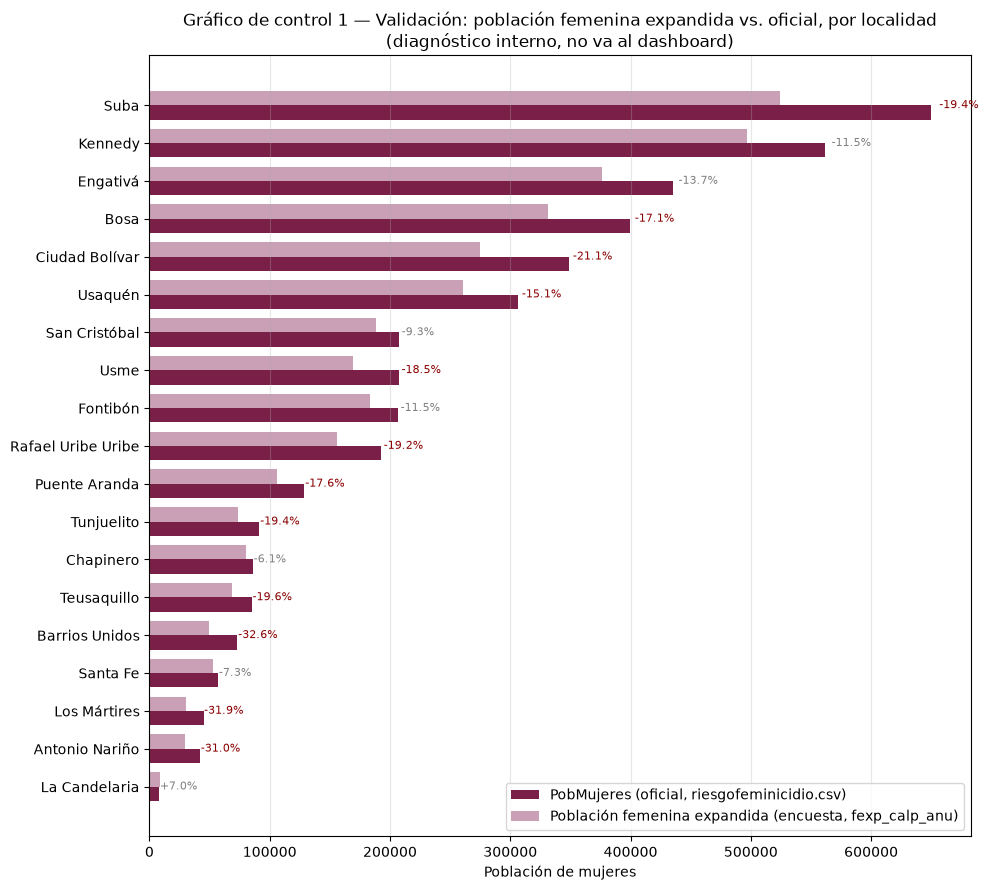


Localidades con diferencia > 15% respecto a PobMujeres oficial:
    nombre_oficial   diff_pct
    Antonio Nariño -31.015527
      Los Mártires -31.910049
    Barrios Unidos -32.640249
       Teusaquillo -19.619854
        Tunjuelito -19.405982
     Puente Aranda -17.568034
Rafael Uribe Uribe -19.211297
              Usme -18.496006
           Usaquén -15.102955
    Ciudad Bolívar -21.145541
              Bosa -17.149182
              Suba -19.414457


In [24]:
import matplotlib.pyplot as plt

# Población femenina expandida desde la encuesta: sexo al nacer = Mujer, suma de fexp_calp_anu por localidad
# (D1 ya viene traducido a texto según diccionario_mapeo.py: "Mujer")
df_mujeres = df.loc[df["D1"] == "Mujer"]

pob_mujer_expandida = (
    df_mujeres.groupby("codigo_localidad")["fexp_calp_anu"].sum()
    .rename("PobMujeres_expandida_encuesta")
)

comparacion_mujeres = dim_localidad.merge(pob_mujer_expandida, on="codigo_localidad", how="left")
comparacion_mujeres = comparacion_mujeres.loc[comparacion_mujeres["en_encuesta"]]  # excluye Sumapaz, no tiene encuesta

# Diferencia porcentual, para anotar en el gráfico
comparacion_mujeres["diff_pct"] = (
    (comparacion_mujeres["PobMujeres_expandida_encuesta"] - comparacion_mujeres["PobMujeres"])
    / comparacion_mujeres["PobMujeres"] * 100
)

comparacion_mujeres = comparacion_mujeres.sort_values("PobMujeres", ascending=True)

print(comparacion_mujeres[["nombre_oficial", "PobMujeres", "PobMujeres_expandida_encuesta", "diff_pct"]].to_string(index=False))

# --- Gráfico de barras horizontales enfrentadas ---
fig, ax = plt.subplots(figsize=(10, 9))

y_pos = np.arange(len(comparacion_mujeres))
ancho = 0.38

ax.barh(y_pos - ancho/2, comparacion_mujeres["PobMujeres"], height=ancho,
        label="PobMujeres (oficial, riesgofeminicidio.csv)", color="#7a2048")
ax.barh(y_pos + ancho/2, comparacion_mujeres["PobMujeres_expandida_encuesta"], height=ancho,
        label="Población femenina expandida (encuesta, fexp_calp_anu)", color="#c9a0b5")

ax.set_yticks(y_pos)
ax.set_yticklabels(comparacion_mujeres["nombre_oficial"])
ax.set_xlabel("Población de mujeres")
ax.set_title("Gráfico de control 1 — Validación: población femenina expandida vs. oficial, por localidad\n"
             "(diagnóstico interno, no va al dashboard)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)

# Anotar diferencia porcentual al final de cada par de barras
for i, (_, row) in enumerate(comparacion_mujeres.iterrows()):
    x_max = max(row["PobMujeres"], row["PobMujeres_expandida_encuesta"])
    ax.text(x_max * 1.01, i, f"{row['diff_pct']:+.1f}%", va="center", fontsize=8,
            color="darkred" if abs(row["diff_pct"]) > 15 else "gray")

plt.tight_layout()
plt.savefig("../../docs/grafico_control_1_pobmujeres.png", dpi=150, bbox_inches="tight")
plt.show()

# Alerta si alguna localidad excede la misma tolerancia del Paso 1.7
TOLERANCIA_LOCAL = 0.15
localidades_fuera_tolerancia = comparacion_mujeres.loc[comparacion_mujeres["diff_pct"].abs() > TOLERANCIA_LOCAL * 100]
if not localidades_fuera_tolerancia.empty:
    print(f"\nLocalidades con diferencia > {TOLERANCIA_LOCAL:.0%} respecto a PobMujeres oficial:")
    print(localidades_fuera_tolerancia[["nombre_oficial", "diff_pct"]].to_string(index=False))
else:
    print(f"\nTodas las localidades dentro de {TOLERANCIA_LOCAL:.0%} de diferencia respecto a PobMujeres oficial.")

In [25]:
texto_supuesto_1_8 = f"""
## Gráfico de control 1 — Población femenina expandida vs. oficial (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Comparación por localidad entre `PobMujeres` (oficial, `riesgofeminicidio.csv`, corte
{corte_reciente.date()}) y la población femenina estimada desde la Encuesta de Percepción
(suma de `fexp_calp_anu` para `D1 == "Mujer"`, agrupada por `codigo_localidad`).

**Propósito:** control de calidad interno del factor de expansión a nivel de localidad
(no solo a nivel ciudad, como en el Paso 1.7). No se incluye en el dashboard de Tableau —
es un diagnóstico de proceso, guardado en `docs/grafico_control_1_pobmujeres.png`.

**Resultado:** {"todas las localidades caen dentro de ±15% de diferencia respecto a la cifra oficial." if localidades_fuera_tolerancia.empty else f"{len(localidades_fuera_tolerancia)} localidad(es) exceden ±15% de diferencia: " + ", ".join(localidades_fuera_tolerancia["nombre_oficial"].tolist()) + ". Investigar antes de usar estimaciones de localidad específicas de estas zonas con alta confianza."}

Diferencia relativa promedio (valor absoluto) entre localidades: {comparacion_mujeres['diff_pct'].abs().mean():.1f}%.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_1_8)

print("Constancia del gráfico de control agregada a docs/supuestos.md")

Constancia del gráfico de control agregada a docs/supuestos.md


Celda — Diagnóstico: ¿el patrón se explica por la exclusión de menores de 18?

In [26]:
# Si la subestimación es por exclusión de menores, debería correlacionar con la
# proporción de población infantil/adolescente esperada en cada localidad —
# localidades con estructura poblacional más joven deberían subestimar MÁS.

# Proxy disponible: A4 (menores de 18 en el hogar) vs A3 (tamaño total del hogar),
# como indicador de la "juventud" relativa de cada localidad en la propia encuesta
prop_menores_hogar = (
    df.groupby("codigo_localidad")
    .apply(lambda g: g["A4"].sum() / g["A3"].sum(), include_groups=False)
    .rename("prop_menores_en_hogares")
)

comparacion_mujeres = comparacion_mujeres.merge(prop_menores_hogar, on="codigo_localidad", how="left")

correlacion = comparacion_mujeres[["diff_pct", "prop_menores_en_hogares"]].corr().iloc[0, 1]
print(f"Correlación entre diff_pct (subestimación) y proporción de menores en el hogar: {correlacion:.3f}")
print("(se espera negativa y fuerte: a mayor proporción de menores, mayor subestimación de PobMujeres)")

print("\n" + comparacion_mujeres[["nombre_oficial", "diff_pct", "prop_menores_en_hogares"]]
      .sort_values("prop_menores_en_hogares", ascending=False).to_string(index=False))

# --- Chequeo directo: suma total oficial vs suma total encuesta, a nivel ciudad ---
suma_oficial_total = comparacion_mujeres["PobMujeres"].sum()
suma_encuesta_total = comparacion_mujeres["PobMujeres_expandida_encuesta"].sum()
diff_ciudad = (suma_encuesta_total - suma_oficial_total) / suma_oficial_total * 100
print(f"\nSuma ciudad — PobMujeres oficial: {suma_oficial_total:,.0f}")
print(f"Suma ciudad — Mujeres adultas expandidas (encuesta): {suma_encuesta_total:,.0f}")
print(f"Diferencia relativa a nivel ciudad: {diff_ciudad:.1f}%")

Correlación entre diff_pct (subestimación) y proporción de menores en el hogar: 0.023
(se espera negativa y fuerte: a mayor proporción de menores, mayor subestimación de PobMujeres)

    nombre_oficial   diff_pct  prop_menores_en_hogares
    Ciudad Bolívar -21.145541                 0.262500
              Usme -18.496006                 0.249006
              Bosa -17.149182                 0.225093
     San Cristóbal  -9.307056                 0.221579
          Fontibón -11.490139                 0.219454
           Usaquén -15.102955                 0.218002
         Chapinero  -6.069581                 0.214080
Rafael Uribe Uribe -19.211297                 0.211487
           Kennedy -11.467810                 0.210693
      Los Mártires -31.910049                 0.201923
          Engativá -13.702651                 0.197742
    Antonio Nariño -31.015527                 0.192063
          Santa Fe  -7.255585                 0.191063
              Suba -19.414457                 0

Celda — Diagnóstico: ¿la variación se explica por tamaño de muestra por localidad?

In [27]:
n_por_localidad = df.groupby("codigo_localidad").size().rename("n_muestra")
comparacion_mujeres = comparacion_mujeres.merge(n_por_localidad, on="codigo_localidad", how="left")

correlacion_n = comparacion_mujeres[["diff_pct", "n_muestra"]].corr().iloc[0, 1]
correlacion_n_abs = comparacion_mujeres.assign(diff_pct_abs=comparacion_mujeres["diff_pct"].abs())[["diff_pct_abs", "n_muestra"]].corr().iloc[0, 1]

print(f"Correlación diff_pct vs n_muestra: {correlacion_n:.3f}")
print(f"Correlación |diff_pct| vs n_muestra: {correlacion_n_abs:.3f}  (se espera negativa: menos muestra, más error)")

print("\n" + comparacion_mujeres[["nombre_oficial", "n_muestra", "PobMujeres", "diff_pct"]]
      .sort_values("n_muestra").to_string(index=False))

Correlación diff_pct vs n_muestra: 0.057
Correlación |diff_pct| vs n_muestra: -0.172  (se espera negativa: menos muestra, más error)

    nombre_oficial  n_muestra  PobMujeres   diff_pct
     La Candelaria        151        8067   7.038165
      Los Mártires        239       45013 -31.910049
    Antonio Nariño        246       42336 -31.015527
    Barrios Unidos        270       73129 -32.640249
         Chapinero        296       85856  -6.069581
          Santa Fe        300       57223  -7.255585
        Tunjuelito        308       91223 -19.405982
       Teusaquillo        335       84932 -19.619854
     Puente Aranda        378      128277 -17.568034
          Fontibón        654      206788 -11.490139
Rafael Uribe Uribe        716      192900 -19.211297
     San Cristóbal        732      207660  -9.307056
              Usme        744      207553 -18.496006
           Usaquén        834      306618 -15.102955
    Ciudad Bolívar        858      348592 -21.145541
          Engativá

In [28]:
texto_supuesto_1_8_cierre = f"""
## Gráfico de control 1 — Diagnóstico de discrepancias por localidad (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

A nivel ciudad, la población femenina expandida desde la encuesta (adultos, `fexp_calp_anu`)
difiere -16.3% de `PobMujeres` oficial (todas las edades). A nivel localidad, 12 de 19
exceden ±15% de diferencia (todas subestiman).

**Hipótesis descartadas por falta de correlación:**
- Proporción de menores en el hogar (proxy de estructura etaria): correlación 0.023 con
  `diff_pct` — no explica la variación entre localidades.
- Tamaño de muestra por localidad: correlación -0.172 con `|diff_pct|` — débil, solo
  visible en los extremos (las 3 localidades de menor `n`: La Candelaria, Los Mártires,
  Antonio Nariño, concentran los errores más extremos en ambas direcciones).

**Conclusión:** la discrepancia responde a una combinación de (1) un componente
sistemático de ciudad, consistente con que `PobMujeres` incluye todas las edades mientras
la encuesta solo mide población adulta (18+), y (2) ruido muestral que se amplifica en
localidades con `n` bajo. No se identifica un error del factor de expansión ni del
pipeline de limpieza — el Paso 1.7 ya confirmó que la suma total del factor es correcta
(1.5% de diferencia contra la población adulta oficial de Bogotá, 6.201.042).

**Regla operativa:** los indicadores basados en la Encuesta de Percepción para
**Los Mártires, Antonio Nariño, Barrios Unidos y La Candelaria** deben reportarse con una
nota de precaución adicional por bajo tamaño muestral (n entre 151 y 270), siguiendo el
mismo criterio ya aplicado a Sumapaz. El resto de localidades (n≥296) se consideran
confiables para estimación, con el entendido de que cualquier tasa que use `PobMujeres`
(todas las edades) como denominador administrativo y un numerador derivado de la encuesta
(solo adultos) tiene un descalce conceptual de denominador que debe declararse en el
dashboard, no ocultarse.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_1_8_cierre)

print("Constancia de cierre agregada a docs/supuestos.md")

Constancia de cierre agregada a docs/supuestos.md
